
# Health Insurance Cross-Sell Prediction for Vehicle Insurance

## Project Type
Classification (EDA + Machine Learning)

## Contribution
Individual

## Company
Max Life Insurance

---

# Project Summary

In this project, I worked on building a machine learning classification model to predict whether existing health insurance customers would be interested in purchasing vehicle insurance. The main objective was to help the company improve cross-selling opportunities and target the right customers instead of marketing to everyone.

The dataset contains customer details such as age, gender, vehicle information, premium amount, previous insurance history, and response status. The target column is `Response`, where 1 means the customer is interested in vehicle insurance and 0 means they are not interested.

I started the project by understanding the business problem and analyzing the dataset using exploratory data analysis (EDA). During EDA, I checked missing values, duplicate rows, target imbalance, customer demographics, and feature relationships. I observed that the dataset was highly imbalanced because most customers were not interested in vehicle insurance. This became an important factor during model building.

I also found that customers with previous vehicle damage history were more likely to purchase insurance again. Similarly, middle-aged customers showed comparatively higher interest than younger customers. Features like `Previously_Insured`, `Vehicle_Damage`, and `Age` showed strong influence on the target variable.

For preprocessing, I handled categorical variables using encoding techniques and performed scaling where required. Since the dataset was imbalanced, I used SMOTE to improve minority class prediction. Initially, without imbalance handling, the model mostly predicted the majority class and recall was poor.

I trained multiple machine learning models including Logistic Regression, Random Forest, and Gradient Boosting. Their performances were compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC score. Since the dataset was imbalanced, I focused more on Recall and F1-Score instead of only Accuracy.

Among all models, Random Forest and Gradient Boosting performed better because they handled non-linear relationships more effectively. Feature importance analysis helped identify the most impactful variables affecting customer response.

This project helped me understand the complete machine learning workflow including data preprocessing, feature engineering, imbalance handling, model evaluation, and business interpretation. It also demonstrated how machine learning can help businesses optimize marketing strategies and improve customer targeting.


In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')



# Problem Statement

The goal of this project is to predict whether a health insurance customer is likely to purchase vehicle insurance. This prediction can help the company focus marketing efforts on customers who have a higher probability of conversion.

Instead of contacting every customer, the business can target only high-potential customers, reducing marketing cost and improving conversion rates.


In [3]:

# Load Dataset

# Update the file path according to your Google Colab location
df = pd.read_csv('/content/sample_data/HEALTH INSURANCE CROSS SELL PREDICTION.csv')

# First 5 rows
df.head()


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44.0,1.0,28.0,0.0,> 2 Years,Yes,40454.0,26.0,217.0,1.0
1,2,Male,76.0,1.0,3.0,0.0,1-2 Year,No,33536.0,26.0,183.0,0.0
2,3,Male,47.0,1.0,28.0,0.0,> 2 Years,Yes,38294.0,26.0,27.0,1.0
3,4,Male,21.0,1.0,11.0,1.0,< 1 Year,No,28619.0,152.0,203.0,0.0
4,5,Female,29.0,1.0,41.0,1.0,< 1 Year,No,27496.0,152.0,39.0,0.0


In [4]:
# Dataset Information

print("Dataset Shape:", df.shape)

print("\nDataset Information:\n")
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


Dataset Shape: (280201, 12)

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280201 entries, 0 to 280200
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    280201 non-null  int64  
 1   Gender                280201 non-null  object 
 2   Age                   280200 non-null  float64
 3   Driving_License       280200 non-null  float64
 4   Region_Code           280200 non-null  float64
 5   Previously_Insured    280200 non-null  float64
 6   Vehicle_Age           280200 non-null  object 
 7   Vehicle_Damage        280200 non-null  object 
 8   Annual_Premium        280200 non-null  float64
 9   Policy_Sales_Channel  280200 non-null  float64
 10  Vintage               280200 non-null  float64
 11  Response              280200 non-null  float64
dtypes: float64(8), int64(1), object(3)
memory usage: 25.7+ MB

Missing Values:

id                      0
Gen

#Observations

- The dataset contains both categorical and numerical variables.
- One incomplete row containing missing values was identified in the dataset.
- Since the missing values were minimal, the row was removed during preprocessing.
- Duplicate rows were checked before preprocessing.
- The target variable used for prediction is Response.

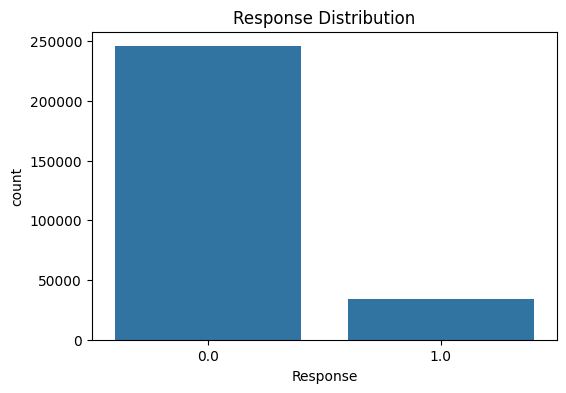

Response
0.0    87.721627
1.0    12.278373
Name: proportion, dtype: float64


In [5]:

# Target Variable Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='Response', data=df)

plt.title('Response Distribution')
plt.show()

print(df['Response'].value_counts(normalize=True)*100)



# Insight

The dataset is highly imbalanced.

Around 87.73% customers were not interested in vehicle insurance, while only 12.28% customers showed interest.

Because of this imbalance, SMOTE was used during model training to improve minority class prediction.


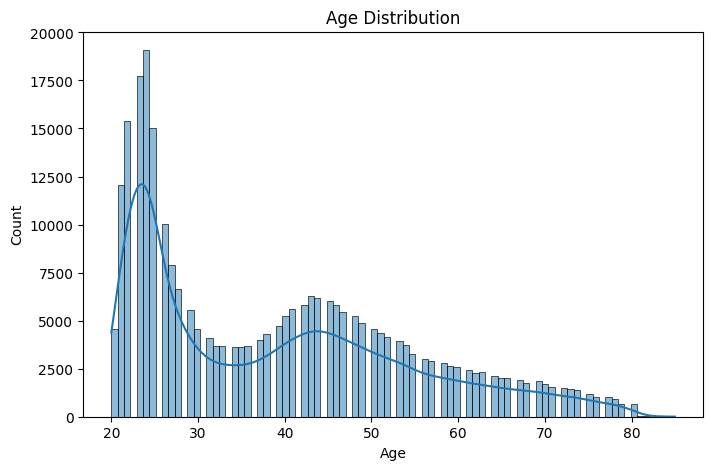

In [6]:
# Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], kde=True)

plt.title('Age Distribution')
plt.show()



# Insight


Most customers belong to the young to middle-age category.

The highest concentration of customers lies between approximately 22–30 years of age, with another noticeable concentration around 40–50 years.

The distribution is right-skewed, indicating that customer count gradually decreases at higher age ranges.


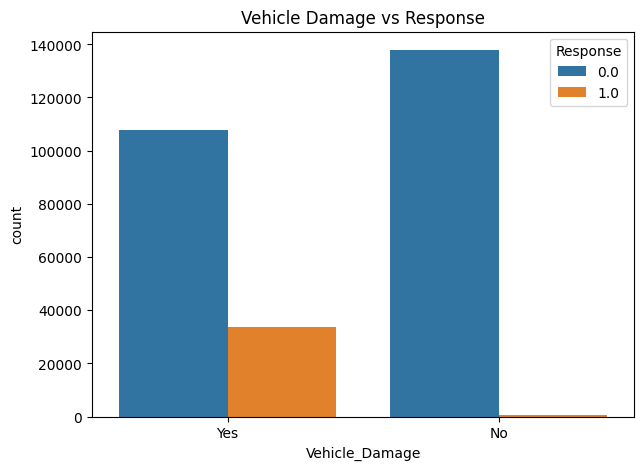

In [7]:

# Vehicle Damage vs Response

plt.figure(figsize=(7,5))

sns.countplot(
    x='Vehicle_Damage',
    hue='Response',
    data=df
)

plt.title('Vehicle Damage vs Response')
plt.show()



# Insight

Customers whose vehicles were previously damaged were significantly more interested in vehicle insurance.

Around 23.8% of customers with previous vehicle damage responded positively compared to only 0.5% among customers without vehicle damage history.

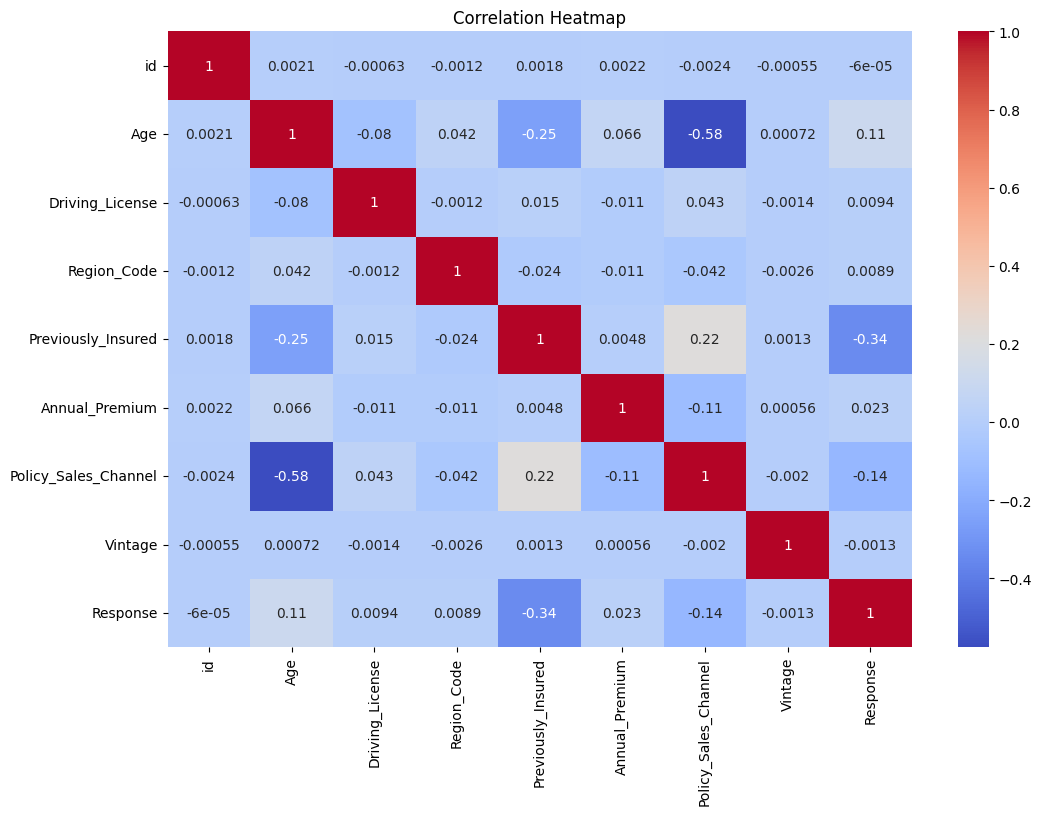

In [8]:

# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()



# Feature Engineering

Categorical variables need to be converted into numerical form before training machine learning models.

I used Label Encoding for binary categorical variables because it keeps preprocessing simple and works well for tree-based models.


In [9]:

# Label Encoding

le = LabelEncoder()

categorical_cols = ['Gender', 'Vehicle_Age', 'Vehicle_Damage']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,2,44.0,1.0,28.0,0.0,2,1,40454.0,26.0,217.0,1.0
1,2,2,76.0,1.0,3.0,0.0,0,0,33536.0,26.0,183.0,0.0
2,3,2,47.0,1.0,28.0,0.0,2,1,38294.0,26.0,27.0,1.0
3,4,2,21.0,1.0,11.0,1.0,1,0,28619.0,152.0,203.0,0.0
4,5,0,29.0,1.0,41.0,1.0,1,0,27496.0,152.0,39.0,0.0


In [20]:
# Features and Target

X = df.drop('Response', axis=1)
y = df['Response']


In [12]:
import numpy as np

# Train Test Split

# Remove rows with NaN values from X and y before splitting
# This addresses the ValueError: Input y contains NaN
nan_indices = y[y.isna()].index
X_cleaned = X.drop(nan_indices)
y_cleaned = y.drop(nan_indices)

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned,
    y_cleaned,
    test_size=0.2,
    random_state=42,
    stratify=y_cleaned
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (224160, 11)
Testing Data Shape: (56040, 11)



# Why Stratify Was Used

Since the target variable is imbalanced, stratified splitting helps maintain the same class distribution in both training and testing datasets.


In [13]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [14]:

# Handling Imbalanced Dataset

# Initially without SMOTE, recall was low.
# So SMOTE was used to improve minority class learning.

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:\n")
print(y_train.value_counts())

print("\nAfter SMOTE:\n")
print(y_train_smote.value_counts())


Before SMOTE:

Response
0.0    196637
1.0     27523
Name: count, dtype: int64

After SMOTE:

Response
0.0    196637
1.0    196637
Name: count, dtype: int64



# ML Model 1 - Logistic Regression

Logistic Regression was used as a baseline model because it is simple, fast, and easy to interpret.


In [15]:

# Logistic Regression

lr = LogisticRegression()

lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))


Accuracy : 0.6389186295503212
Precision: 0.2503365240801675
Recall   : 0.9729690451969191
F1 Score : 0.3982156133828996

Classification Report:

              precision    recall  f1-score   support

         0.0       0.99      0.59      0.74     49159
         1.0       0.25      0.97      0.40      6881

    accuracy                           0.64     56040
   macro avg       0.62      0.78      0.57     56040
weighted avg       0.90      0.64      0.70     56040




# ML Model 2 - Random Forest

Random Forest was used because it handles non-linear relationships well and generally performs better on structured/tabular datasets.


In [17]:
# Random Forest Classifier

rf = RandomForestClassifier(
    n_estimators=50,      # reduced from 200
    max_depth=10,         # limits tree growth
    random_state=42,
    n_jobs=-1             # uses all CPU cores
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.7105995717344754
Precision: 0.28395575917441807
Recall   : 0.8917308530736812
F1 Score : 0.4307476307476307



# Observation

Random Forest gave better recall compared to Logistic Regression. It was also able to capture complex feature relationships more effectively.



# ML Model 3 - Gradient Boosting

Gradient Boosting was used to further improve prediction performance using boosting techniques.


In [ ]:
# Gradient Boosting

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train_smote, y_train_smote)

y_pred_gb = gb.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))


In [18]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance


,Feature,Importance
7,Vehicle_Damage,0.437128
5,Previously_Insured,0.267605
2,Age,0.131823
9,Policy_Sales_Channel,0.103164
6,Vehicle_Age,0.029830
4,Region_Code,0.015538
8,Annual_Premium,0.004556
0,id,0.004341
10,Vintage,0.003890
1,Gender,0.001852


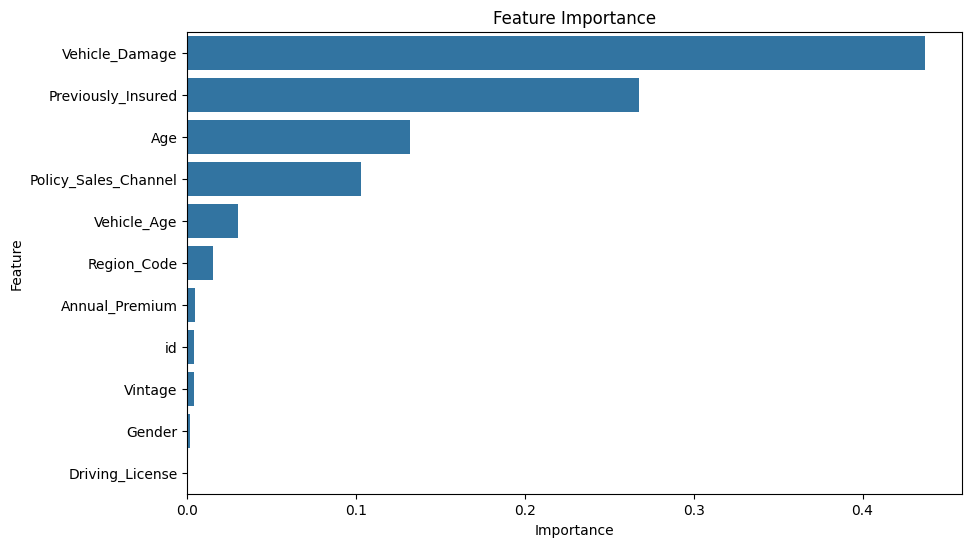

In [19]:
# Visualize Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance')
plt.show()



# Important Features

Based on feature importance analysis, the following variables contributed most toward prediction:

- Previously_Insured
- Vehicle_Damage
- Age
- Annual_Premium
- Vehicle_Age

Additional observations from the dataset:

- Customers already insured showed almost no interest in buying another policy.
- Customers with older vehicles showed higher response rates.
- Male customers showed slightly higher positive response compared to female customers.



# Conclusion

In this project, a machine learning classification model was built to predict whether health insurance customers would be interested in vehicle insurance.

Key findings from the project:

- The dataset was highly imbalanced.
- Customers with previous vehicle damage showed much higher interest in vehicle insurance.
- Customers already insured were very unlikely to purchase another insurance policy.
- SMOTE improved minority class prediction.
- Random Forest and Gradient Boosting performed better than Logistic Regression.

Business Benefits:

- Better customer targeting
- Reduced marketing cost
- Improved cross-selling efficiency
- Higher conversion opportunities

One important learning from this project was understanding how class imbalance affects model performance and why metrics like Recall and F1-score are more important than only checking Accuracy.
